# 01. Исследование исходных данных

На этом этапе проверяем структуру набора `consumption.parquet`: период наблюдений, состав категорий, число муниципалитетов, дубликаты и пропуски. Цель - убедиться, что исходные данные пригодны для дальнейшего формирования экономических признаков.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Все библиотеки подключились!")

Все библиотеки подключились!


## 1. Загрузка данных

Загружаем исходные потребительские расходы муниципалитетов за весь доступный период.

In [2]:
consumption = pd.read_parquet(
    "../data/raw/consumption.parquet"
)

print("Файл загружен!")

Файл загружен!


## 2. Первичный просмотр

Сначала посмотрим несколько строк и размер таблицы, чтобы понимать ее структуру до дальнейших проверок.

In [3]:
consumption.head()

,date,territory_id,category,value
0,2023-01,1,Продовольствие,7692
1,2023-01,1,Здоровье,1271
2,2023-01,1,Маркетплейсы,2505
3,2023-01,1,Общественное питание,1142
5,2023-01,1,Транспорт,1718


In [4]:
consumption.shape

(303126, 4)

In [5]:
consumption.info()

<class 'pandas.DataFrame'>
Index: 303126 entries, 0 to 353646
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   date          303126 non-null  str  
 1   territory_id  303126 non-null  int16
 2   category      303126 non-null  str  
 3   value         303126 non-null  int32
dtypes: int16(1), int32(1), str(2)
memory usage: 17.9 MB


## 3. Состав экономических категорий

Проверяем, какие категории расходов присутствуют в данных. Эти категории станут основой будущего вектора экономических признаков муниципалитета.

In [6]:
consumption["category"].unique()

<ArrowStringArray>
[      'Продовольствие',             'Здоровье',         'Маркетплейсы',
 'Общественное питание',            'Транспорт',        'Все категории']
Length: 6, dtype: str

## 4. Временной охват

Проверяем минимальную и максимальную дату и убеждаемся, что панель действительно охватывает требуемый период.

In [7]:
consumption["date"].min(), consumption["date"].max()

('2023-01', '2024-12')

## 5. Покрытие по муниципалитетам

Определяем число уникальных `territory_id`, чтобы оценить масштаб исследования.

In [8]:
consumption["territory_id"].nunique()

2190

## 6. Проверка дубликатов

Для каждой комбинации муниципалитет-месяц-категория должна существовать не более одной записи.

In [9]:
duplicates = consumption.duplicated(
    subset=["territory_id", "date", "category"]
).sum()

print("Количество дубликатов:", duplicates)

Количество дубликатов: 0


## 7. Проверка пропусков

Проверяем, есть ли отсутствующие значения в исходных потребительских расходах.

In [10]:
consumption.isna().sum()

date            0
territory_id    0
category        0
value           0
dtype: int64

## 8. Покрытие муниципалитетов по месяцам

Проверяем, насколько стабильно число муниципалитетов меняется по месяцам. Важно для построения динамической сети.

In [11]:
municipalities_by_month = (
    consumption
    .groupby("date")["territory_id"]
    .nunique()
)

municipalities_by_month

date
2023-01    2143
2023-02    2141
2023-03    2149
2023-04    2129
2023-05    2121
2023-06    2119
2023-07    2126
2023-08    2118
2023-09    2109
2023-10    2103
2023-11    2093
2023-12    2103
2024-01    2072
2024-02    2078
2024-03    2083
2024-04    2087
2024-05    2085
2024-06    2084
2024-07    2089
2024-08    2094
2024-09    2100
2024-10    2092
2024-11    2100
2024-12    2103
Name: territory_id, dtype: int64

## 9. Визуальная проверка покрытия

График позволяет быстро увидеть возможные провалы или изменения покрытия панели во времени.

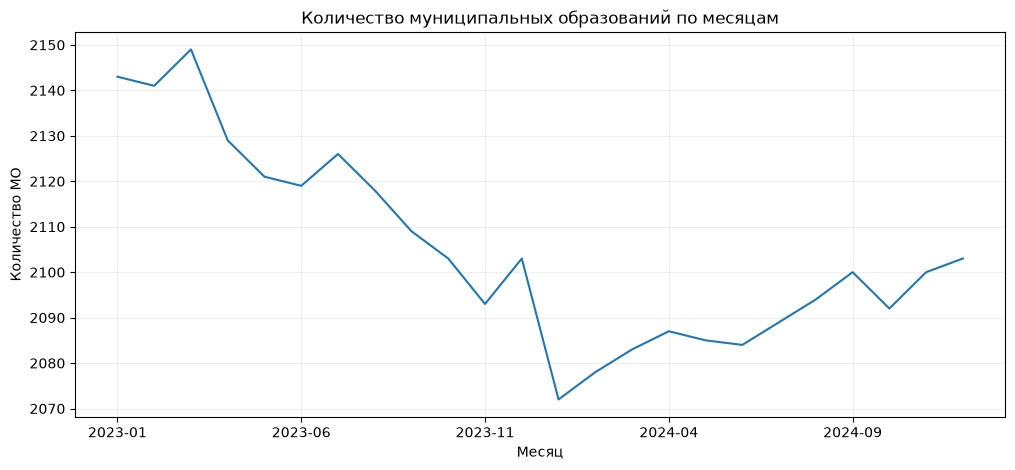

In [12]:
plt.figure(figsize=(12, 5))

municipalities_by_month.plot()

plt.title("Количество муниципальных образований по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество МО")

plt.grid(alpha=0.2)
plt.show()